In [79]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.notebook_repr_html', True)

In [80]:
# === METRICS & LABELS ===
metrics = [
    'relevance',
    'clarity',
    'answerability',
    'challenging',
    'value',
    'language',
    'bloom_rating',
    "blooms_level_score"
 ]
metric_labels = {
    'relevance': 'Relevance',
    'clarity': 'Clarity',
    'answerability': 'Answerability',
    'challenging': 'Challenging',
    'value': 'Value',
    'language': 'Language',
    'bloom_rating': "Bloom's Level (Student)",
    'blooms_level_score': "Bloom's Level (Score)"
}

In [81]:
base_path = Path("../60_analyses/csv/qualitative/exp2/students")

BASE_PROJECT_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
hint_base_path = os.path.join(BASE_PROJECT_PATH, "20_experiments/60_analyses/csv/qualitative/exp2/hints")
output_base_path = os.path.join(BASE_PROJECT_PATH, "40_evaluation/exp2/qualitative")
output_tables_path = os.path.join(output_base_path, "tables")
output_plots_path = os.path.join(output_base_path, "plots")

for path in [output_tables_path, output_plots_path]:
    os.makedirs(path, exist_ok=True)

tables = {}
plots = {}

In [82]:
def load_student_data(student_id):
    student_path = base_path / f"student_{student_id}"
    data = {}
    
    for exp in ["exp2a", "exp2b", "exp2c"]:
        csv_path = student_path / f"{exp}.csv"
        if csv_path.exists():
            # Try multiple encodings to handle German characters
            df = None
            for encoding in ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']:
                try:
                    df = pd.read_csv(csv_path, encoding=encoding)
                    break
                except UnicodeDecodeError:
                    continue
            
            if df is None:
                print(f"Error: Could not read {csv_path} with any encoding")
                continue
            
            if 'comments' in df.columns:
                df = df.drop('comments', axis=1)

            if 'answer_problems' in df.columns:
                df = df.drop('answer_problems', axis=1)
            
            df['sample_id'] = df['sample_id'].astype(str)
            if 'question_num' not in df.columns:
                df['question_num'] = df['sample_id'].str.extract('(\\d+)').astype(int).iloc[:, 0]
            
            df['student'] = student_id
            df['experiment'] = exp
            data[exp] = df
            print(f"Loaded {exp} for student_{student_id}: {len(df)} questions")
    
    return data


def load_hint_data():
    hint_data = {}
    for exp in ["exp2a", "exp2b", "exp2c"]:
        hint_path = os.path.join(hint_base_path, f"{exp}_hints.csv")
        if os.path.exists(hint_path):
            hint_df = None
            for encoding in ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']:
                try:
                    hint_df = pd.read_csv(hint_path, encoding=encoding)
                    break
                except UnicodeDecodeError:
                    continue
            if hint_df is None:
                print(f"Error: Could not read {hint_path} with any encoding")
                continue
            if exp == 'exp2a':
                if 'question_id' not in hint_df.columns:
                    print(f"Warning: No question_id column found in {exp}_hints.csv")
                    continue
                hint_df['question_id'] = hint_df['question_id'].astype(str)
                print(f"Loaded {exp}_hints.csv: {len(hint_df)} rows")
                hint_data[exp] = hint_df
            elif exp in ['exp2b', 'exp2c'] and 'bloom_original' in hint_df.columns:
                hint_df = hint_df.copy()
                hint_df['bloom_original'] = hint_df['bloom_original'].astype(str)
                # DO NOT set question_id = index!
                print(f"Loaded {exp}_hints.csv: {len(hint_df)} rows (no question_id, using row order)")
                hint_data[exp] = hint_df
            else:
                print(f"Warning: No suitable columns found in {exp}_hints.csv")
    return hint_data

all_data = {}
for i in range(1, 4):
    all_data[f"student_{i}"] = load_student_data(i)

hint_data = load_hint_data()

Loaded exp2a for student_1: 16 questions
Loaded exp2b for student_1: 8 questions
Loaded exp2c for student_1: 16 questions
Loaded exp2a for student_2: 16 questions
Loaded exp2b for student_2: 8 questions
Loaded exp2c for student_2: 16 questions
Loaded exp2a for student_3: 16 questions
Loaded exp2b for student_3: 8 questions
Loaded exp2c for student_3: 16 questions
Loaded exp2a_hints.csv: 16 rows
Loaded exp2b_hints.csv: 8 rows (no question_id, using row order)
Loaded exp2c_hints.csv: 16 rows (no question_id, using row order)


In [83]:
def combine_data():
    combined = []
    print("\n--- Combining all available student data (no overlap filtering) ---")
    for student, experiments in all_data.items():
        print(f"\n{student}:")
        for exp, df in experiments.items():
            if not df.empty:
                if exp in hint_data:
                    hint_df = hint_data[exp]
                    # Always use row-wise assignment if lengths match
                    if len(df) == len(hint_df):
                        df_merged = df.copy()
                        for col in hint_df.columns:
                            if col not in df_merged.columns:
                                df_merged[col] = hint_df[col].values
                        print(f"  {exp}: {len(df_merged)} evaluations (row-wise assignment: {list(hint_df.columns)})")
                    else:
                        print(f"  {exp}: Could not row-wise assign hint data (len(df)={len(df)}, len(hint_df)={len(hint_df)})")
                        df_merged = df
                    combined.append(df_merged)
                else:
                    print(f"  {exp}: {len(df)} evaluations (no hint data available)")
                    combined.append(df)
    if combined:
        return pd.concat(combined, ignore_index=True)
    return pd.DataFrame()

df_combined = combine_data()
print(f"\n=== FINAL SUMMARY ===")
print(f"Total evaluations: {len(df_combined)}")

if len(df_combined) > 0:
    print(f"\nBreakdown by student:")
    for student_id in sorted(df_combined['student'].unique()):
        student_data = df_combined[df_combined['student'] == student_id]
        print(f"  Student {student_id}: {len(student_data)} evaluations")
        for exp in ["exp2a", "exp2b", "exp2c"]:
            exp_data = student_data[student_data['experiment'] == exp]
            if len(exp_data) > 0:
                questions = sorted(exp_data['question_num'].unique())
                print(f"    {exp}: {len(exp_data)} evaluations, Questions: {questions}")
else:
    print("No data loaded. Check if CSV files exist and contain data.")


--- Combining all available student data (no overlap filtering) ---

student_1:
  exp2a: 16 evaluations (row-wise assignment: ['llm', 'question_id', 'question_type'])
  exp2b: 8 evaluations (row-wise assignment: ['llm', 'bloom_original'])
  exp2c: 16 evaluations (row-wise assignment: ['llm', 'bloom_original', 'question_type'])

student_2:
  exp2a: 16 evaluations (row-wise assignment: ['llm', 'question_id', 'question_type'])
  exp2b: 8 evaluations (row-wise assignment: ['llm', 'bloom_original'])
  exp2c: 16 evaluations (row-wise assignment: ['llm', 'bloom_original', 'question_type'])

student_3:
  exp2a: 16 evaluations (row-wise assignment: ['llm', 'question_id', 'question_type'])
  exp2b: 8 evaluations (row-wise assignment: ['llm', 'bloom_original'])
  exp2c: 16 evaluations (row-wise assignment: ['llm', 'bloom_original', 'question_type'])

=== FINAL SUMMARY ===
Total evaluations: 120

Breakdown by student:
  Student 1: 40 evaluations
    exp2a: 16 evaluations, Questions: [np.int64(1),

# Experiment 2: Descriptive Statistics

Analysis of prompt engineering approaches for question generation.

In [84]:
def convert_bloom_rating_simple(value, experiment, given_level=None):

    bloom_map = {
        6: 10,
        5: 8.5,
        4: 7,
        3: 4.5,
        2: 3,
        1: 1.5
    }
    import re
    def extract_levels(val):
        if isinstance(val, str):
            nums = re.findall(r'\d+', val)
            return [int(n) for n in nums] if nums else []
        elif isinstance(val, (int, float)) and not pd.isnull(val):
            return [int(val)]
        return []

    if experiment == 'exp2a':
        levels = extract_levels(value)
        if levels:
            max_level = max(levels)
            return bloom_map.get(max_level, np.nan)
        return np.nan
    elif experiment in ['exp2b', 'exp2c']:
        rater_levels = extract_levels(value)
        given_levels = extract_levels(given_level) if given_level is not None else []
        if not rater_levels or not given_levels:
            return np.nan
        best_score = 0
        for r in rater_levels:
            for g in given_levels:
                if r == g:
                    best_score = max(best_score, 10)
                elif abs(r - g) == 1:
                    best_score = max(best_score, 5)
        if best_score == 0:
            return 0
        return best_score
    else:
        return np.nan

EXPERIMENT 2 - DESCRIPTIVE STATISTICS (ALL RATINGS)
Number of ratings in df_combined: 120
Converting metrics to numeric (all ratings)...


,sample_id,relevance,clarity,answerability,challenging,value,language,bloom_rating,question_num,student,experiment,llm,question_id,question_type,bloom_original,blooms_level_score
0,1,10,10.0,10,4,8,10,1,1,1,exp2a,anthropic,2,multiple_choice,NaN,1.5
1,2,8,8.0,10,8,8,7,2,2,1,exp2a,anthropic,6,multiple_choice,NaN,3.0
2,3,8,8.0,8,10,8,7,4,3,1,exp2a,anthropic,5,open_ended,NaN,7.0
3,4,10,8.0,8,10,8,10,(4;2),4,1,exp2a,anthropic,6,open_ended,NaN,7.0
4,5,8,10.0,6,2,4,7,1,5,1,exp2a,deepseek,4,multiple_choice,NaN,1.5
5,6,8,8.0,8,8,8,7,(1;2),6,1,exp2a,deepseek,5,multiple_choice,NaN,3.0
6,7,10,10.0,8,8,8,10,(1;2),7,1,exp2a,deepseek,4,open_ended,NaN,3.0
7,8,10,10.0,8,10,8,10,(1;2),8,1,exp2a,deepseek,6,open_ended,NaN,3.0
8,9,10,10.0,10,6,8,10,2,9,1,exp2a,google,4,multiple_choice,NaN,3.0
9,10,8,10.0,6,6,10,10,2,10,1,exp2a,google,6,multiple_choice,NaN,3.0



Overall Statistics (ALL RATINGS, all metrics on 0-10 scale):


,relevance,clarity,answerability,challenging,value,language,blooms_level_score
count,120.00,119.00,120.00,120.00,120.00,120.00,120.00
mean,-27.43,8.92,-28.61,7.02,8.57,8.52,6.82
std,50.84,1.62,50.95,2.55,1.76,1.96,3.57
min,-99.00,2.00,-99.00,0.00,0.00,3.00,0.00
25%,-99.00,8.00,-99.00,6.00,8.00,7.00,3.00
50%,8.00,10.00,6.00,8.00,8.00,10.00,8.50
75%,10.00,10.00,8.50,8.00,10.00,10.00,10.00
max,10.00,10.00,10.00,10.00,10.00,10.00,10.00



Statistics by Experiment (ALL RATINGS):


relevance              clarity             answerability         \
                mean    std count    mean   std count          mean    std   
experiment                                                                   
exp2a         -26.96  51.49    48    8.79  1.69    48        -27.50  51.12   
exp2b         -27.58  51.61    24    8.43  2.00    23        -32.79  52.42   
exp2c         -27.83  50.88    48    9.29  1.27    48        -27.62  51.03   

                 challenging             value             language        \
           count        mean   std count  mean   std count     mean   std   
experiment                                                                  
exp2a         48        7.17  2.29    48  8.58  1.49    48     8.44  2.26   
exp2b         24        8.42  1.86    24  8.75  1.42    24     8.33  1.88   
exp2c         48        6.17  2.79    48  8.46  2.15    48     8.71  1.69   

                 blooms_level_score              
           count               mean   std count  
experiment                                       
exp2a         48               4.03  2.51    48  
exp2b         24               8.75  3.38    24  
exp2c         48               8.65  2.68    48


Questions per Experiment:
  exp2a: Questions [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)] (48 ratings)
  exp2b: Questions [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)] (24 ratings)
  exp2c: Questions [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)] (48 ratings)

=== VISUALIZATION: PERFORMANCE BY EXPERIMENT ===
Saved collective experiment boxplot: /home/malde/git/bachelor-thesis/40_evaluation/exp2/qualitative/plots/exp2_boxplots_all_metrics_by_experiment.png
Saved collective experiment boxplot: /home/malde/git/bachelor-thesis/40_evaluation/exp2/qualitative/plots/exp2_boxplots_all_metrics_by_exper

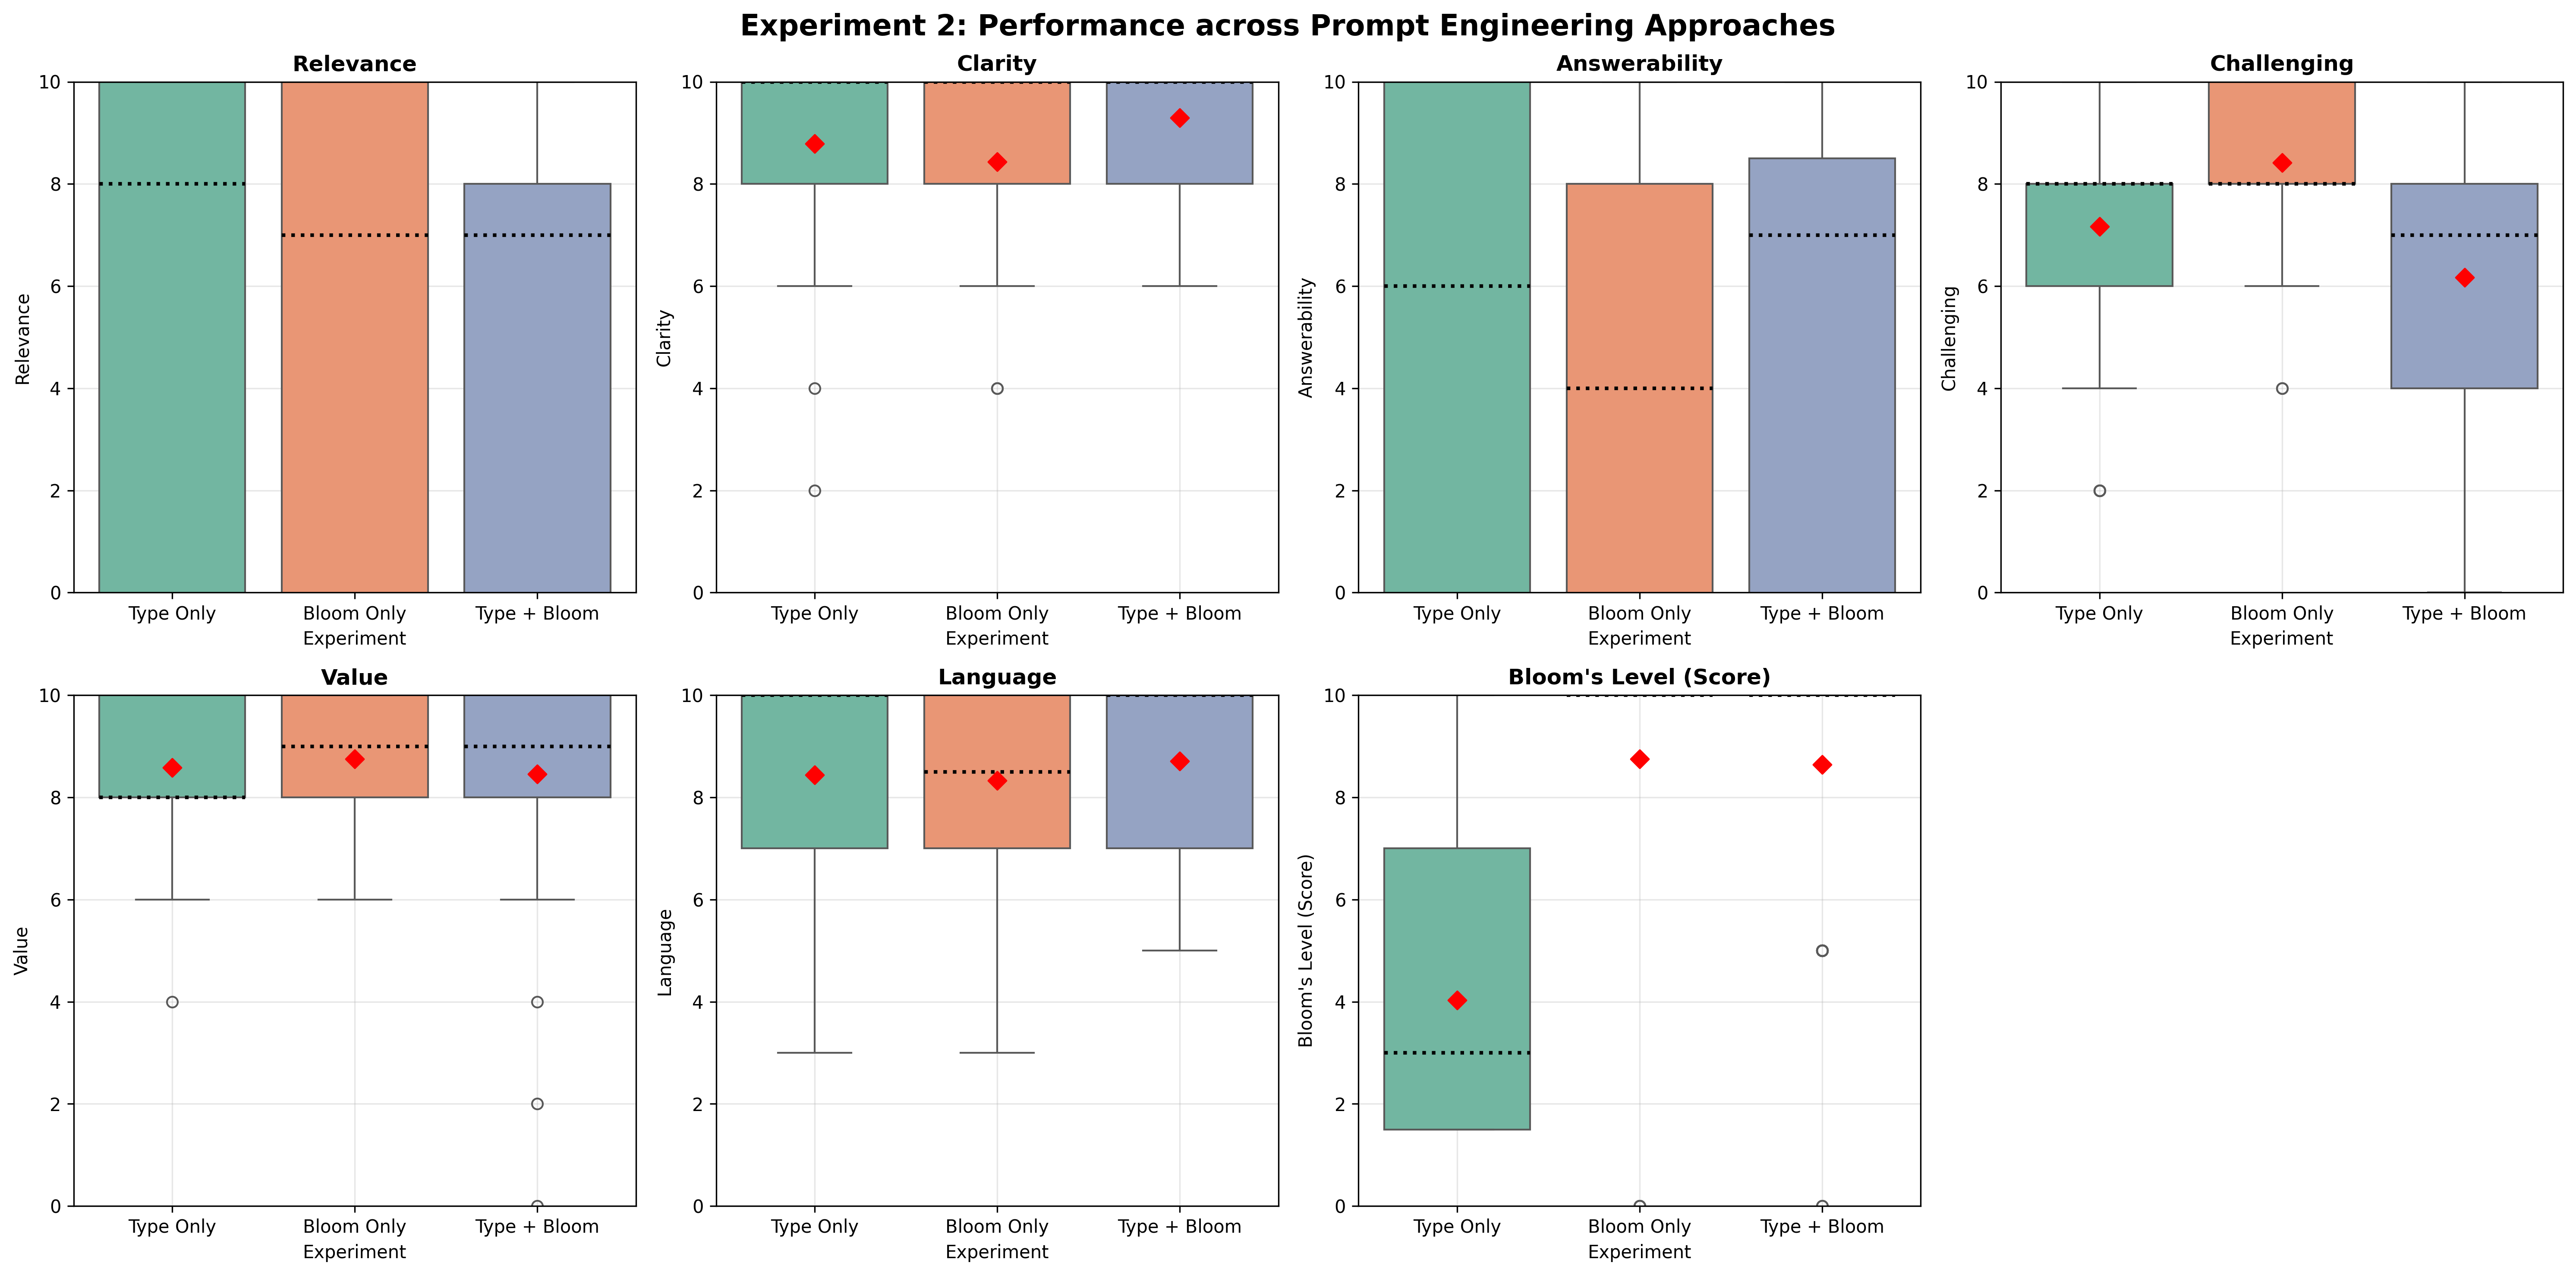

Visualization complete.
Note: This visualization includes all 120 ratings.


In [85]:
# --- DESCRIPTIVE STATISTICS & PLOTS: ALL RATINGS (NO OVERLAP FILTERING) ---

print("EXPERIMENT 2 - DESCRIPTIVE STATISTICS (ALL RATINGS)")
print("="*70)
print(f"Number of ratings in df_combined: {len(df_combined)}")

# Create consistent numeric dataset for all ratings
df_numeric = df_combined.copy()

print("Converting metrics to numeric (all ratings)...")
for metric in metrics:
    if metric == 'bloom_rating':
        # bloom_rating bleibt das Rating der Studierenden
        df_numeric[metric] = df_combined[metric]
    elif metric == 'blooms_level_score':
        def bloom_score_apply(row):
            if row['experiment'] in ['exp2b', 'exp2c'] and 'bloom_original' in row and not pd.isnull(row['bloom_original']):
                return convert_bloom_rating_simple(row['bloom_rating'], row['experiment'], row['bloom_original'])
            else:
                return convert_bloom_rating_simple(row['bloom_rating'], row['experiment'])
        df_numeric[metric] = df_combined.apply(bloom_score_apply, axis=1)
    else:
        df_numeric[metric] = pd.to_numeric(df_combined[metric], errors='coerce')

display(df_numeric)

# Nur numerische Spalten für Statistik und Plots verwenden
numeric_metrics = [m for m in metrics if pd.api.types.is_numeric_dtype(df_numeric[m])]

# Basic statistics - ALL ratings
if len(df_numeric) > 0 and numeric_metrics:
    print("\nOverall Statistics (ALL RATINGS, all metrics on 0-10 scale):")
    overall_stats = df_numeric[numeric_metrics].describe().round(2)
    display(overall_stats)

    print("\nStatistics by Experiment (ALL RATINGS):")
    exp_stats = df_numeric.groupby('experiment')[numeric_metrics].agg(['mean', 'std', 'count']).round(2)
    display(exp_stats)
    
    print(f"\nQuestions per Experiment:")
    for exp in ["exp2a", "exp2b", "exp2c"]:
        exp_data = df_numeric[df_numeric['experiment'] == exp]
        if len(exp_data) > 0:
            questions = sorted(exp_data['question_num'].unique())
            print(f"  {exp}: Questions {questions} ({len(exp_data)} ratings)")
        else:
            print(f"  {exp}: No questions")
else:
    print("\nNo ratings available for statistics.")
    overall_stats = pd.DataFrame()
    exp_stats = pd.DataFrame()

# --- PLOTS: ALL RATINGS ---
print("\n=== VISUALIZATION: PERFORMANCE BY EXPERIMENT ===")

if len(df_numeric) > 0 and numeric_metrics:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, metric in enumerate(numeric_metrics):
        df_plot = df_numeric[[metric, 'experiment']].dropna()
        if len(df_plot) > 0:
            metric_display = metric_labels[metric]
            colors = ['#66c2a5', '#fc8d62', '#8da0cb']
            sns.boxplot(data=df_plot, x='experiment', y=metric, ax=axes[i], palette=colors,
                        medianprops={'color': 'black', 'linewidth': 2, 'linestyle': ':'})
            for j, exp in enumerate(['exp2a', 'exp2b', 'exp2c']):
                exp_data = df_plot[df_plot['experiment'] == exp][metric]
                if len(exp_data) > 0:
                    mean_val = exp_data.mean()
                    axes[i].scatter(j, mean_val, color='red', marker='D', s=50, zorder=3)
            axes[i].set_ylim(0, 10)
            axes[i].set_title(f'{metric_display}', fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Experiment')
            axes[i].set_ylabel(metric_display)
            axes[i].grid(True, alpha=0.3)
            axes[i].set_xticklabels(['Type Only', 'Bloom Only', 'Type + Bloom'])
        else:
            axes[i].set_title(f'{metric_labels[metric]} - No Data')
            axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[i].transAxes)
    for j in range(len(numeric_metrics), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Experiment 2: Performance across Prompt Engineering Approaches', fontsize=16, fontweight='bold')
    plt.tight_layout()
    # Save the entire figure as one PNG
    if 'output_plots_path' in locals():
        figpath = os.path.join(output_plots_path, "exp2_boxplots_all_metrics_by_experiment.png")
        fig.savefig(figpath)
        print(f"Saved collective experiment boxplot: {figpath}")
    plt.show()
    print("Visualization complete.")
    print(f"Note: This visualization includes all {len(df_numeric)} ratings.")
else:
    print("No data available for visualization.")

# Metric Analysis by LLM

The following section provides boxplots and summary tables for all metrics, grouped by LLM (language model).


=== METRIC ANALYSIS BY LLM ===
Saved collective LLM boxplot: /home/malde/git/bachelor-thesis/40_evaluation/exp2/qualitative/plots/exp2_boxplots_all_metrics_by_llm.png
Saved collective LLM boxplot: /home/malde/git/bachelor-thesis/40_evaluation/exp2/qualitative/plots/exp2_boxplots_all_metrics_by_llm.png


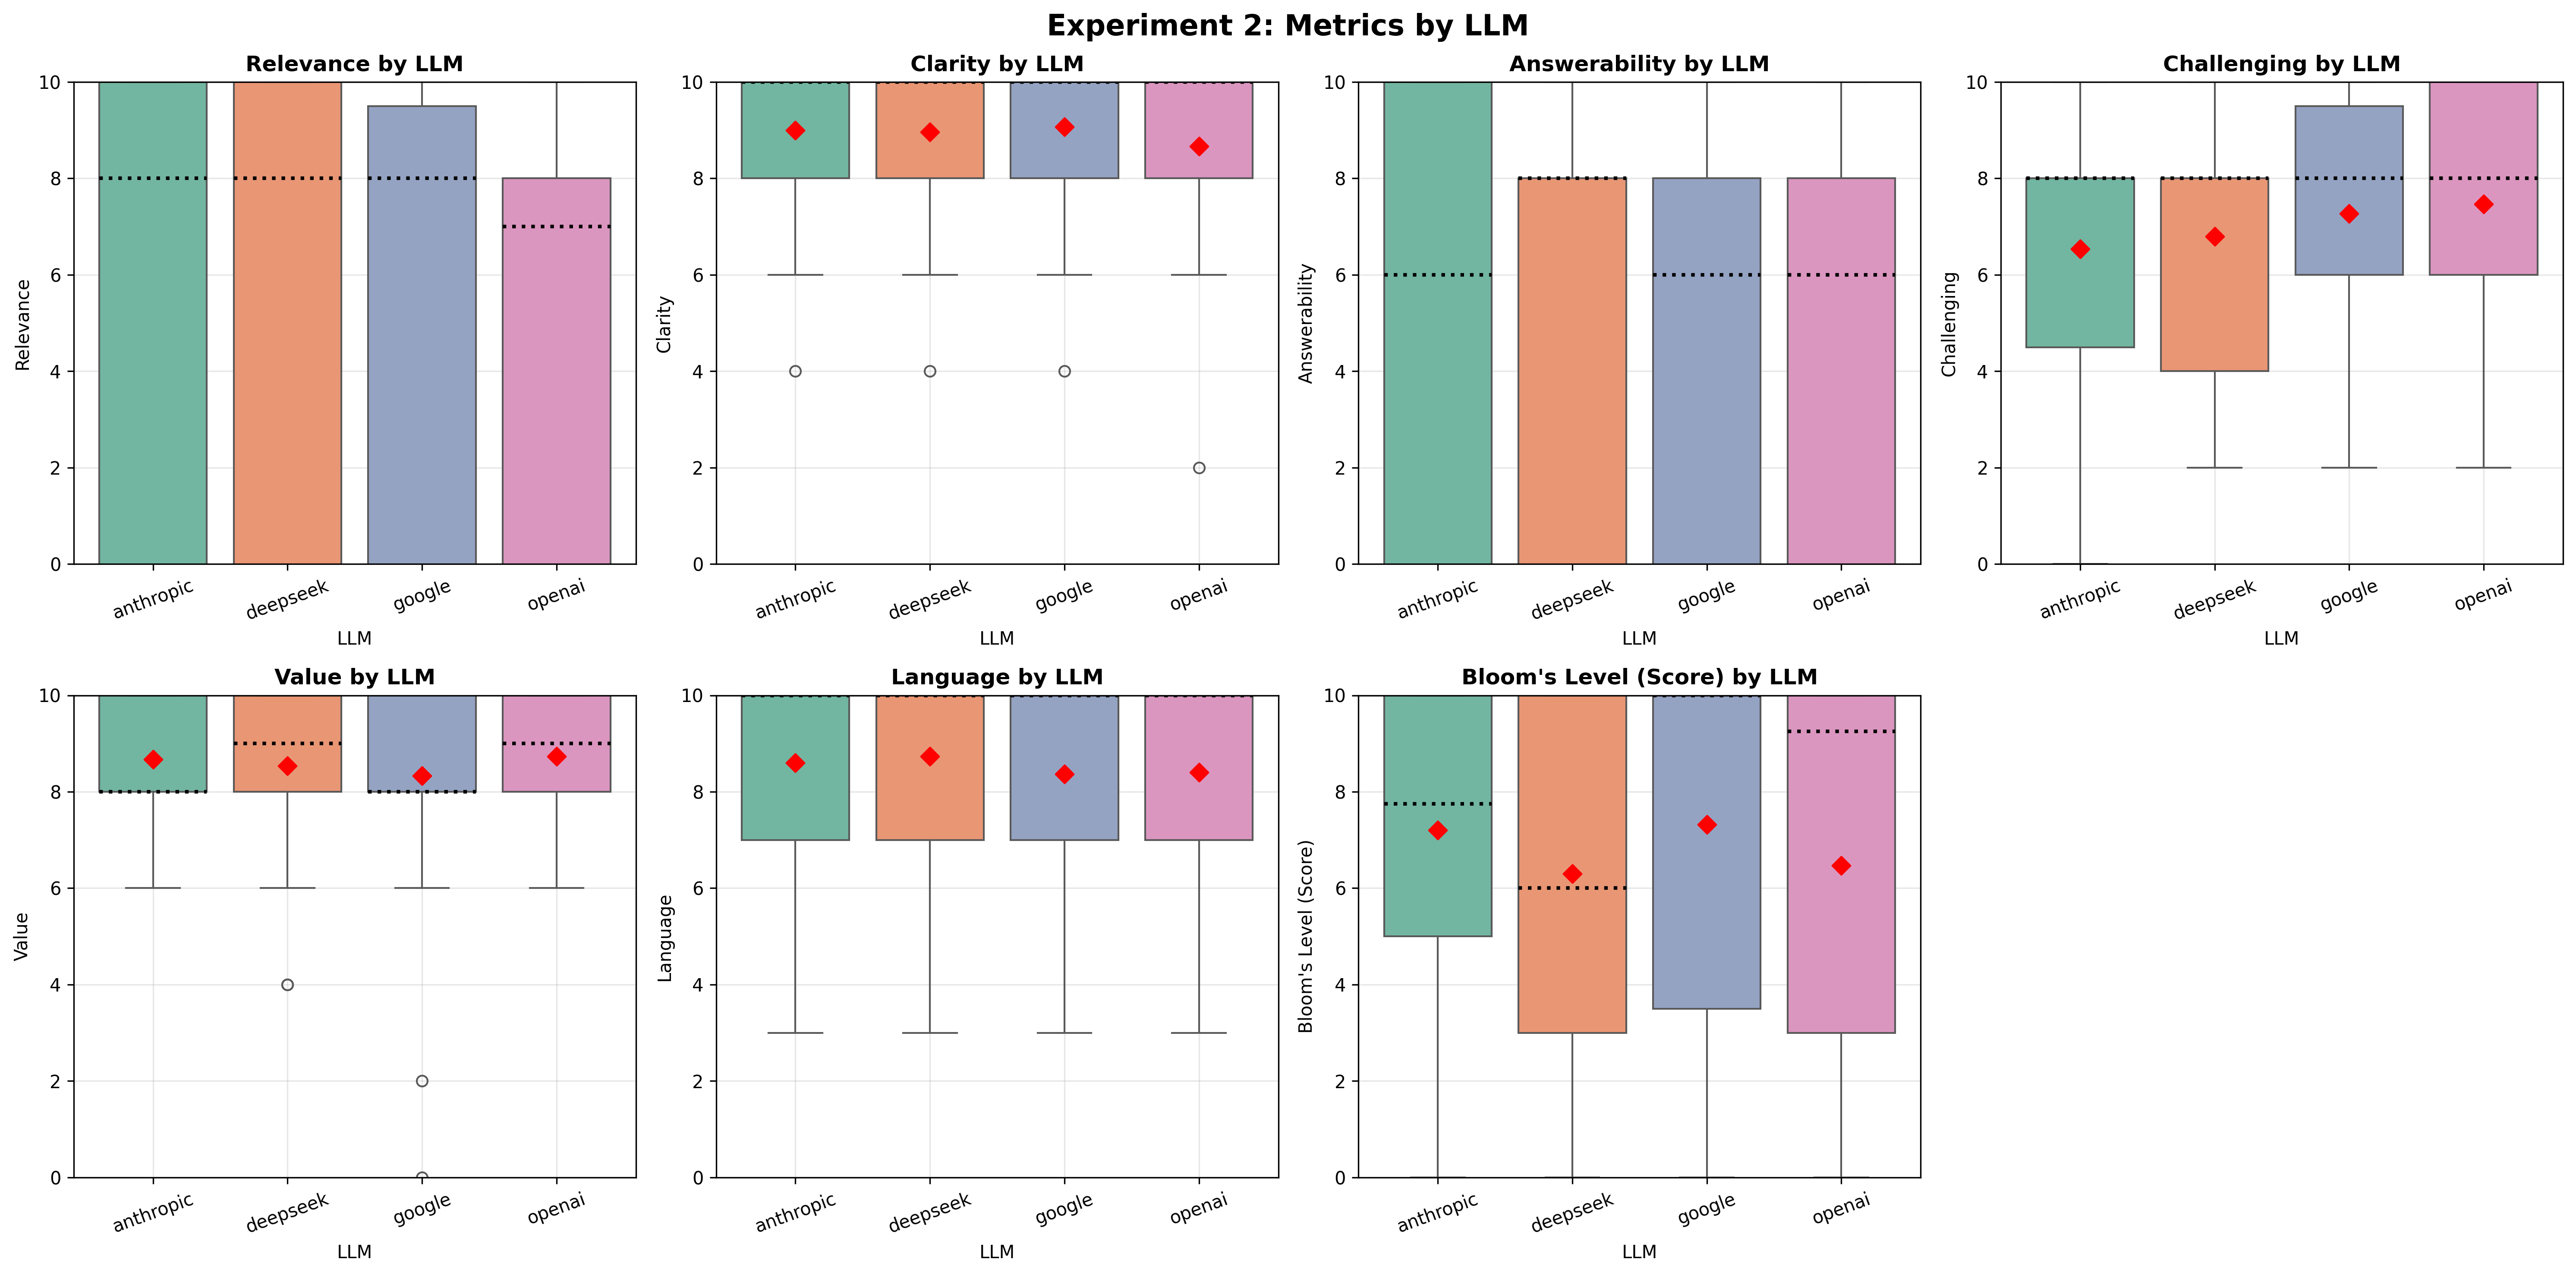

Visualization by LLM complete.
Note: This visualization includes all 120 ratings.

Summary Table: Metrics by LLM (mean, std, count)


relevance              clarity             answerability         \
               mean    std count    mean   std count          mean    std   
llm                                                                         
anthropic    -27.07  51.75    30    9.00  1.64    30        -27.40  51.51   
deepseek     -27.40  51.52    30    8.97  1.57    29        -27.67  51.33   
google       -27.53  51.42    30    9.07  1.46    30        -31.37  52.37   
openai       -27.73  51.27    30    8.67  1.84    30        -28.00  51.09   

                challenging             value             language        \
          count        mean   std count  mean   std count     mean   std   
llm                                                                        
anthropic    30        6.53  2.57    30  8.67  1.32    30     8.60  2.06   
deepseek     30        6.80  2.55    30  8.53  1.81    30     8.73  1.87   
google       30        7.27  2.70    30  8.33  2.35    30     8.37  2.08   
openai       30        7.47  2.40    30  8.73  1.44    30     8.40  1.90   

                blooms_level_score              
          count               mean   std count  
llm                                             
anthropic    30               7.20  3.27    30  
deepseek     30               6.30  3.74    30  
google       30               7.32  3.41    30  
openai       30               6.47  3.90    30

Saved metrics by LLM table to /home/malde/git/bachelor-thesis/40_evaluation/exp2/qualitative/tables


In [86]:
# --- BOXPLOTS & TABLES: METRICS BY LLM ---

print("\n=== METRIC ANALYSIS BY LLM ===")

if 'df_numeric' in locals() and 'llm' in df_numeric.columns and len(df_numeric) > 0 and numeric_metrics:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, metric in enumerate(numeric_metrics):
        df_plot = df_numeric[[metric, 'llm']].dropna()
        if len(df_plot) > 0:
            metric_display = metric_labels.get(metric, metric)
            colors = sns.color_palette("Set2", n_colors=df_plot['llm'].nunique())
            sns.boxplot(data=df_plot, x='llm', y=metric, ax=axes[i], palette=colors,
                        medianprops={'color': 'black', 'linewidth': 2, 'linestyle': ':'})
            for j, llm_name in enumerate(sorted(df_plot['llm'].unique())):
                llm_data = df_plot[df_plot['llm'] == llm_name][metric]
                if len(llm_data) > 0:
                    mean_val = llm_data.mean()
                    axes[i].scatter(j, mean_val, color='red', marker='D', s=50, zorder=3)
            axes[i].set_ylim(0, 10)
            axes[i].set_title(f'{metric_display} by LLM', fontsize=12, fontweight='bold')
            axes[i].set_xlabel('LLM')
            axes[i].set_ylabel(metric_display)
            axes[i].grid(True, alpha=0.3)
            axes[i].set_xticklabels(sorted(df_plot['llm'].unique()), rotation=20)
        else:
            axes[i].set_title(f'{metric_labels[metric]} - No Data')
            axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[i].transAxes)
    for j in range(len(numeric_metrics), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Experiment 2: Metrics by LLM', fontsize=16, fontweight='bold')
    plt.tight_layout()
    # Save the entire figure as one PNG
    if 'output_plots_path' in locals():
        figpath = os.path.join(output_plots_path, "exp2_boxplots_all_metrics_by_llm.png")
        fig.savefig(figpath)
        print(f"Saved collective LLM boxplot: {figpath}")
    plt.show()
    print("Visualization by LLM complete.")
    print(f"Note: This visualization includes all {len(df_numeric)} ratings.")

    # --- TABLES: METRICS BY LLM ---
    print("\nSummary Table: Metrics by LLM (mean, std, count)")
    llm_stats = df_numeric.groupby('llm')[numeric_metrics].agg(['mean', 'std', 'count']).round(2)
    display(llm_stats)
    if 'output_tables_path' in locals():
        llm_stats.to_csv(os.path.join(output_tables_path, "exp2_metrics_by_llm.csv"))
        print(f"Saved metrics by LLM table to {output_tables_path}")

else:
    print("No data available for LLM-based analysis.")

In [87]:
# --- TABLE: LLM vs. Prompt Type (Experiment) for Bloom's Level Scoring ---

print("\n=== TABLE: LLM vs. Prompt Type (Experiment) for Bloom's Level Scoring ===")

if 'df_numeric' in locals() and 'llm' in df_numeric.columns and 'experiment' in df_numeric.columns and 'blooms_level_score' in df_numeric.columns:
    llm_prompt_bloom = df_numeric.pivot_table(index='llm', columns='experiment', values='blooms_level_score', aggfunc=['mean', 'std', 'median']).round(2)
    display(llm_prompt_bloom)
    if 'output_tables_path' in locals():
        llm_prompt_bloom.to_csv(os.path.join(output_tables_path, "exp2_llm_vs_prompttype_bloomslevel.csv"))
        print(f"Saved LLM vs. Prompt Type Bloom's Level table to {output_tables_path}")

else:
    print("Not enough data for LLM vs. Prompt Type Bloom's Level table.")


=== TABLE: LLM vs. Prompt Type (Experiment) for Bloom's Level Scoring ===


mean                std             median            
experiment exp2a  exp2b exp2c exp2a exp2b exp2c  exp2a exp2b exp2c
llm                                                               
anthropic   5.08   8.33  8.75  2.71  4.08  2.26    7.0  10.0  10.0
deepseek    2.83   8.33  8.75  1.50  4.08  2.26    3.0  10.0  10.0
google      4.54   8.33  9.58  2.53  4.08  1.44    3.0  10.0  10.0
openai      3.67  10.00  7.50  2.78  0.00  3.99    3.0  10.0  10.0

Saved LLM vs. Prompt Type Bloom's Level table to /home/malde/git/bachelor-thesis/40_evaluation/exp2/qualitative/tables


# Inter-Student Reliability Analysis

Analysis of agreement between student evaluators on overlapping questions.

In [ ]:
print("\n" + "="*60)
print("FLEISS' KAPPA INTER-RATER RELIABILITY ANALYSIS")
print("="*60)

from statsmodels.stats.inter_rater import fleiss_kappa

def make_global_question_id(row):
    if row['experiment'] == 'exp2a':
        return f"{row['experiment']}|{row['llm']}|{row['question_id']}|{row['question_type']}"
    elif row['experiment'] == 'exp2b':
        return f"{row['experiment']}|{row['llm']}|{row['bloom_original']}"
    elif row['experiment'] == 'exp2c':
        return f"{row['experiment']}|{row['llm']}|{row['bloom_original']}|{row['question_type']}"
    else:
        return None

df_numeric['global_question_id'] = df_numeric.apply(make_global_question_id, axis=1)

def kappa_level(k):
    if k < 0:
        return "Invalid"
    if k < 0.2:
        return "Slight"
    elif k < 0.4:
        return "Fair"
    elif k < 0.6:
        return "Moderate"
    elif k < 0.8:
        return "Substantial"
    else:
        return "Almost Perfect"

def calculate_fleiss_kappa_all_questions(df, metrics, experiment_col='experiment'):
    results = []
    for exp in sorted(df[experiment_col].unique()):
        exp_df = df[df[experiment_col] == exp]
        for metric in metrics:
            pivot = exp_df.pivot_table(index='global_question_id', columns='student', values=metric)
            ratings_matrix = pivot.applymap(lambda x: max(1, min(10, int(round(x)))) if pd.notnull(x) else np.nan).values
            fleiss_table = np.zeros((ratings_matrix.shape[0], 10))
            for i, row in enumerate(ratings_matrix):
                for r in row:
                    if not np.isnan(r) and 1 <= r <= 10:
                        fleiss_table[i, int(r)-1] += 1
            all_identical = np.all((fleiss_table == np.max(fleiss_table, axis=1, keepdims=True)) | (fleiss_table == 0), axis=1)
            try:
                if np.all(all_identical):
                    kappa = 1.0
                else:
                    kappa = fleiss_kappa(fleiss_table)
            except Exception:
                kappa = np.nan
            results.append({
                'Experiment': exp,
                'Metric': metric_labels.get(metric, metric),
                'Fleiss_Kappa': kappa,
                'Agreement_Level': kappa_level(kappa) if not np.isnan(kappa) else 'No data',
                'N_Questions': ratings_matrix.shape[0]
            })
    return pd.DataFrame(results)

def calculate_fleiss_kappa_compact(df, metrics):
    results = []
    for metric in metrics:
        pivot = df.pivot_table(index='global_question_id', columns='student', values=metric)
        ratings_matrix = pivot.applymap(lambda x: max(1, min(10, int(round(x)))) if pd.notnull(x) else np.nan).values
        fleiss_table = np.zeros((ratings_matrix.shape[0], 10))
        for i, row in enumerate(ratings_matrix):
            for r in row:
                if not np.isnan(r) and 1 <= r <= 10:
                    fleiss_table[i, int(r)-1] += 1
        all_identical = np.all((fleiss_table == np.max(fleiss_table, axis=1, keepdims=True)) | (fleiss_table == 0), axis=1)
        try:
            if np.all(all_identical):
                kappa = 1.0
            else:
                kappa = fleiss_kappa(fleiss_table)
        except Exception:
            kappa = np.nan
        results.append({
            'Metric': metric_labels.get(metric, metric),
            'Fleiss_Kappa': kappa,
            'Agreement_Level': kappa_level(kappa) if not np.isnan(kappa) else 'No data',
            'N_Questions': ratings_matrix.shape[0]
        })
    return pd.DataFrame(results)

kappa_all_df = calculate_fleiss_kappa_all_questions(df_numeric, numeric_metrics)
print("\nFleiss' Kappa Calculation:")
display(kappa_all_df.round(4))
if 'output_tables_path' in locals():
    kappa_all_df.to_csv(os.path.join(output_tables_path, "exp2_fleiss_kappa_all_questions.csv"), index=False)
    print(f"Saved full Fleiss' Kappa table to {output_tables_path}")

kappa_compact_df = calculate_fleiss_kappa_compact(df_numeric, numeric_metrics)
print("\nFleiss' Kappa Calculation (ALL QUESTIONS, ALL EXPERIMENTS):")
display(kappa_compact_df.round(4))
if 'output_tables_path' in locals():
    kappa_compact_df.to_csv(os.path.join(output_tables_path, "exp2_fleiss_kappa_all_questions_compact.csv"), index=False)
    print(f"Saved compact Fleiss' Kappa table to {output_tables_path}")


FLEISS' KAPPA INTER-RATER RELIABILITY ANALYSIS

Fleiss' Kappa Calculation:


,Experiment,Metric,Fleiss_Kappa,Agreement_Level,N_Questions
0,exp2a,Relevance,-0.3248,Invalid,16
1,exp2a,Clarity,-0.2203,Invalid,16
2,exp2a,Answerability,-0.1817,Invalid,16
3,exp2a,Challenging,0.1971,Slight,16
4,exp2a,Value,-0.2722,Invalid,16
5,exp2a,Language,-0.0062,Invalid,16
6,exp2a,Bloom's Level (Score),0.0938,Slight,16
7,exp2b,Relevance,-0.2279,Invalid,8
8,exp2b,Clarity,NaN,No data,8
9,exp2b,Answerability,-0.1009,Invalid,8


Saved full Fleiss' Kappa table to /home/malde/git/bachelor-thesis/40_evaluation/exp2/qualitative/tables

Fleiss' Kappa Calculation (ALL QUESTIONS, ALL EXPERIMENTS):


,Metric,Fleiss_Kappa,Agreement_Level,N_Questions
0,Relevance,-0.2389,Invalid,40
1,Clarity,NaN,No data,40
2,Answerability,-0.1352,Invalid,40
3,Challenging,0.2696,Fair,40
4,Value,-0.2557,Invalid,40
5,Language,0.0161,Slight,40
6,Bloom's Level (Score),0.3735,Fair,40


Saved compact Fleiss' Kappa table to /home/malde/git/bachelor-thesis/40_evaluation/exp2/qualitative/tables


In [ ]:
#TODO add fleiss kappa between student pairs

In [90]:
def save_results():
    print("Saving key results (based on all ratings)...")
    
    if 'overall_stats' in locals() and not overall_stats.empty:
        overall_stats.to_csv(os.path.join(output_tables_path, "exp2_overall_statistics_all.csv"))
        print("Saved overall statistics (all ratings)")
    
    if 'exp_stats' in locals() and not exp_stats.empty:
        exp_stats.to_csv(os.path.join(output_tables_path, "exp2_experiment_statistics_all.csv"))
        print("Saved experiment statistics (all ratings)")
    
    if 'kappa_all_df' in locals() and not kappa_all_df.empty:
        kappa_all_df.to_csv(os.path.join(output_tables_path, "exp2_fleiss_kappa_all.csv"), index=False)
        print("Saved Fleiss' Kappa results (all ratings)")
    
    if 'kappa_compact_df' in locals() and not kappa_compact_df.empty:
        kappa_compact_df.to_csv(os.path.join(output_tables_path, "exp2_fleiss_kappa_all_compact.csv"), index=False)
        print("Saved compact Fleiss' Kappa results (all ratings)")
    
    print(f"\nResults saved to: {output_tables_path}")

# Execute save
save_results()

print(f"\n" + "="*60)
print("ANALYSIS COMPLETE - ALL RATINGS")
print("="*60)
print(f"Data loaded: {len(df_combined)} total evaluations")
print(f"Metrics analyzed: {len(metrics)}")
print(f"Students: {sorted(df_combined['student'].unique())}")
print(f"Experiments: {sorted(df_combined['experiment'].unique())}")

Saving key results (based on all ratings)...

Results saved to: /home/malde/git/bachelor-thesis/40_evaluation/exp2/qualitative/tables

ANALYSIS COMPLETE - ALL RATINGS
Data loaded: 120 total evaluations
Metrics analyzed: 8
Students: [np.int64(1), np.int64(2), np.int64(3)]
Experiments: ['exp2a', 'exp2b', 'exp2c']
